# [Open in Google Colab](https://colab.research.google.com/github/Jechen00/segformer-pytorch/blob/main/notebooks/segformer_b1_training.ipynb)

# **Note**: The logs are from training on an A100 GPU

In [ ]:
import torch
from torch import nn
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import AdamW

import sys, os
import gdown
import random
from pathlib import Path
from IPython.display import clear_output, display


# -----------------------------------------------------------
# Check if running in Google Colab
try:
    import google.colab
    print('\033[1m[ALERT]\033[0m Running in Google Colab.')
    
    IN_COLAB = True
    REPO_ROOT = Path('./segformer-pytorch')

except ImportError:
    print('\033[1m[ALERT]\033[0m Running in segformer-pytorch repository.')
    
    IN_COLAB = False
    REPO_ROOT = Path('..')

# Clone repo if it doesn't exist
if IN_COLAB and (not os.path.exists(REPO_ROOT)):
    print('\033[1m[ALERT]\033[0m Repository not found. Cloning segformer-pytorch from GitHub...')
    
    os.chdir('/content') # Ensure we are in content directory
    !git clone https://github.com/Jechen00/segformer-pytorch.git


# -----------------------------------------------------------
# Import repo modules
sys.path.append(str(REPO_ROOT))

from src.models import SegFormer

from src.data_setup.transforms.pipelines import get_geo_transforms, get_phot_transforms
from src.data_setup.dataloader_utils import build_dataloader
from src.data_setup.datasets import SuperviselyPersonDataset

from src.losses import FocalDiceLoss

from src.metrics import SegmentationMetrics
from src.metrics.postprocess import MetricSpec

from src.engine.trainer_settings import EvalSettings, SchedulerSettings, PerformanceSettings, SaveSettings
from src.engine.measure_policy import MeasurePolicy
from src.engine.trainer import ModelTrainer

from src.utils import ml_utils
from src.engine.checkpoint import separate_checkpoint
from src.visualize.plot_results import plot_loss, plot_summary_metrics, plot_class_metrics
from src.visualize.plot_preds import plot_seg_preds_collage, plot_seg_preds_overlay


# -----------------------------------------------------------
clear_output(wait = True) # Clear cluttered output after setup

ml_utils.set_seed(0) # Set seed for reproducibility
DEVICE = ml_utils.get_device() # Computation device

print(f'\033[1mCPU count:\033[0m {os.cpu_count()}')
print(f'\033[1mDevice:\033[0m {DEVICE}')

CPU count: 12
Device: cuda


# 1) Introduction

In this Google Colab example, we will **train a SegFormer model** on a [**subset of the Supervisely Person dataset**](https://www.kaggle.com/datasets/tapakah68/supervisely-filtered-segmentation-person-dataset). This is a binary segmentation dataset containing the classes: human and background.

This subset of the Supervisely Person dataset contains a total of 2667 samples (each consisting of an image and a mask). For the **training split**, we use roughly 90% of these samples (2400 total), while the **validation split** contains the remaining roughly 10% (267 total).

---



# 2) Partial Supervisely Person Dataset

## 2.1) Set Up Transforms

For both **training and validation**, all images and their corresponding masks are resized to **512x512** using a **letterbox** transform that preserves the aspect ratios. Images are resized using bilinear interpolation, while masks are resized using nearest-neighbor interpolation.


<br>

For **training only**, we use two additional augmentation pipelines: one for photometric augmentations and one for geometric augmentations.

The **geometric augmentations** are applied to both the images and their corresponding masks.
They include:
  - Random horizontal flip
  - Random affine (rotate, translate, scale)
  
The interpolation methods are the same as those used for resizing.

The **photometric augmentations** are applied to only the images. They include:
  - Color jitter
  - Random grayscale conversion
  - Random apply Gaussian blur or sharpening


<br>

Note that **tensor conversion** and **normalization** are not included in these transform pipelines because the dataset provides optional built-in versions that are applied after the user-provided transforms.

The transform pipelines for training and validation are obtained from `transforms.get_geo_transforms` and `transforms.get_phot_transforms`.


In [ ]:
# Resizing values
IMG_SIZE = (512, 512)
SIZING_MODE = 'letterbox'

# Fill value for geo transforms
IMG_FILL = (114, 114, 114)
MASK_FILL = (114, 114, 114)

# ----------------------------------------------------------------
# Training geometric transforms (resizing + augmentations)
train_geo_tfs = get_geo_transforms(
    size = IMG_SIZE,
    sizing_mode = SIZING_MODE,
    img_fill = IMG_FILL,
    mask_fill = MASK_FILL,
    include_augs = True # Include geo augmentations
)

# Training photometric transforms
train_phot_tfs = get_phot_transforms()

# Validation geometric transforms (resizing only)
# This is just a resizing transform because `include_augs=False`
val_geo_tfs = get_geo_transforms(
    size = IMG_SIZE,
    sizing_mode = SIZING_MODE,
    img_fill = IMG_FILL,
    mask_fill = MASK_FILL,
    include_augs = False # Exclude geo augmentations
)

## 2.2) Set Up Datasets

The training and validation splits for the partial Supervisely Person dataset can both be obtained by creating a `datasets.SuperviselyPersonDataset` instance.

<br>

This dataset instance has optional built-in **tensor conversion** (`to_tensor = True`) and **normalization** (`norm_mean` and `norm_std`) that is applied after any user-provided transforms.

The **transform pipeline** in the `SuperviselyPersonDataset` instance can be accessed using the `.transform_pipeline` attribute and is ordered like so:
  1. User-provided geometric transforms
  2. User-provided photometric transforms
  2. Optional image tensor conversion (if `to_tensor=True`)
  3. Optional float32 conversion and scaling (if `to_tensor=True`)
  4. Normalization (if `norm_mean` and `norm_std` are provided)

<br>

The transform pipeline is applied to the **original samples** of the dataset, where each sample contains an image and a corresponding RGB segmentation mask. After transformations are applied, the RGB masks are converted to index masks using a RGB-to-index mapping. This assigns each pixel a class index, making the masks compatible with single-label losses and metrics.

The **RGB and index information** for each class is as follows:
  - **human**:
    - RGB: `(255, 255, 255)`
    - index: `1`
  - **background**:
    - RGB: `(0, 0, 0)`
    - index: `0`

In addition to the class information, we include an **ignore encoding** that maps the `MASK_FILL` color to an ignore index (`-100` in this case) during RGB-to-index mask conversion. This allows the loss and metric computations to ignore pixels introduced by the geometric transforms (e.g. padding), ensuring that only pixels corresponding to the original mask contribute to training and evaluation.

<br>

A fully **processed sample** from the dataset can be obtained by directly indexing it (e.g. `dataset[index]`). This sample is returned as a dictionary containing 2 keys:
  - **image** (`Union[torch.Tensor, Image.Image]`): Sample image after it has passed through the transform pipeline.
  - **mask** (`Union[torch.Tensor, Image.Image]`): Target index mask for the image.

To access a **sample before dataset processing**, we can use the `.get_base_item(index)` method of the `SuperviselyPersonDataset` instance. This returns a sample dictionary containing the image and RGB mask before applying the transform pipeline and RGB-to-index mask conversion. Note that the image and mask are ensured to be in RGB PIL image format for consistency.

In [ ]:
DATA_ROOT = REPO_ROOT / 'data'

# Convert all samples to tensors
TO_TENSOR = True

# Normalize with ImageNet stats after tensor conversion
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

# Ignore fill pixels from geo transforms
IGNORE_ENCODING = {'idx': -100, 'rgb': MASK_FILL}


# ----------------------------------------------------------------
train_dataset = SuperviselyPersonDataset(
    root = REPO_ROOT,
    split = 'train',
    geo_transforms = train_geo_tfs,
    img_phot_transforms = train_phot_tfs,
    to_tensor = TO_TENSOR,
    norm_mean = NORM_MEAN,
    norm_std = NORM_STD,
    ignore_encoding = IGNORE_ENCODING
)

val_dataset = SuperviselyPersonDataset(
    root = REPO_ROOT,
    split = 'val',
    geo_transforms = val_geo_tfs,
    to_tensor = TO_TENSOR,
    norm_mean = NORM_MEAN,
    norm_std = NORM_STD,
    ignore_encoding = IGNORE_ENCODING
)


# ----------------------------------------------------------------
# Clear cluttered output
clear_output(wait = True)

# Print class mapping
NUM_CLASSES = len(train_dataset.class_names)
print(f'Class-to-Index Mapping: {train_dataset.class_to_idx}')

Class-to-Index Mapping: {'human': 1, 'background': 0}


## 2.3) Set Up Dataloaders

The function `dataloader_utils.build_dataloaders` can be used to create dataloaders for the train and validation datasets. Since this example is ran on an A100, the dataloaders will use a **batch size** of 32 and multi-process data loading with 10 **workers**.

A batch from these dataloaders is returned as a dictionary with 2 keys:

- **image** (`torch.Tensor`): Batch of images of shape `(batch_size, channels, height, width)`

- **mask** (`torch.Tensor`): Batch of index masks of shape `(batch_size, height, width)`

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 10

# ----------------------------------------------------------------
train_loader = build_dataloader(
    dataset = train_dataset,
    split = 'train',
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    device = DEVICE
)

val_loader = build_dataloader(
    dataset = val_dataset,
    split = 'val',
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    device = DEVICE
)


# ----------------------------------------------------------------
# Print sample shapes
batched_samp = next(iter(train_loader))

print(f"Batched Image Shape: {batched_samp['image'].shape}")
print(f"Batched Mask Shape: {batched_samp['mask'].shape}")

Batched Image Shape: torch.Size([32, 3, 512, 512])
Batched Mask Shape: torch.Size([32, 512, 512])


# 3) Model

The SegFormer model we will be training uses a **MiT-B1 backbone**.

This model is instantiated as `models.SegFormer`.

<br>

In the original SegFormer paper, the MiT backbones were pretrained on an image classification task using ImageNet-1k. In this example, we instead use a MiT backbone pretrained on a subset of ImageNet-1k known as [**Mini-ImageNet**](https://huggingface.co/datasets/timm/mini-imagenet).

The Google Colab notebook used to pretrain the MiT backbone can be found here: [**mit_b1_pretraining**](https://colab.research.google.com/github/Jechen00/segformer-pytorch/blob/main/notebooks/mit_b1_pretraining.ipynb).

In [ ]:
# SegFormer-B1 Config
segformer_cfg = {
    # Encoder (MiT-B1) config
    'in_channels': 3,
    'feature_dims': (64, 128, 320, 512),
    'patch_sizes': (7, 3, 3, 3),
    'strides': (4, 2, 2, 2),
    'num_blks': (2, 2, 2, 2),
    'num_heads': (1, 2, 5, 8),
    'reduce_ratios': (8, 4, 2, 1),
    'hid_dims': (512, 1024, 1280, 2048),
    'enc_activations': None,  # Defaults to GELU
    'ffn_dropout_probs': 0.05,
    'attn_dropout_probs': 0.05,
    'max_sdepth_prob': 0.1,

    # Decoder config
    'fused_channels': 256,
    'num_classes': NUM_CLASSES,
    'dec_activation': nn.ReLU(),
    'channel_dropout_prob': 0.1
}

segformer = SegFormer(**segformer_cfg)


# ----------------------------------------------------------------
# Download MiT-B1 backbone pretrained on Mini-ImageNet
BACKBONE_PATH = REPO_ROOT / 'saved_models/backbone_pretrain'

if not BACKBONE_PATH.is_dir():
    backbone_url = 'https://drive.google.com/drive/folders/1CWVqNr0BeKhJChCLgeLsEyP_XQ9VLKJL'
    gdown.download_folder(url = backbone_url, output = str(BACKBONE_PATH), quiet = True)

# Load MiT-B1 state dictionary into SegFormer model
mit_state_dict = torch.load(BACKBONE_PATH / 'mini_imagenet/mit_b1/best_backbone.pth')
segformer.encoder.load_state_dict(mit_state_dict)


# ----------------------------------------------------------------
# Print total parameters
total_params = sum(p.numel() for p in segformer.parameters())
print('Total Params:', total_params)

Total Params: 14016194


# 4) Loss and Optimizer

The loss function we use is called the **Focal-Dice loss** (`losses.FocalDiceLoss`), which is a weighted sum between focal loss and Dice loss.

We include an ignore index (`ignore_idx`) in this loss to ensure that only valid pixels in the target mask contribute to training. Additionally, we exclude the background class from the Dice loss using the `exclude_bg_idx` argument to make it consistent with how the loss is applied in binary segmentation.

<br>

The optimizer we use is **AdamW** (`optim.AdamW`), with a starting learning rate of `2.5e-4`. The beta and weight decay values are kept at their default `PyTorch` values.

In [ ]:
# Loss function
loss_fn = FocalDiceLoss(
    lambda_dice = 3.0,
    lambda_focal = 1.0,
    alpha_focal = 0.75,
    gamma_focal = 2.0,
    ignore_idx = train_dataset.ignore_idx,
    exclude_bg_idx = 0 # Exclude background class from Dice loss
)


# Optimizer
optimizer = AdamW(
    segformer.parameters(),
    lr = 2.5e-4,
    betas = (0.9, 0.999),
    weight_decay = 0.01
)

# 5) (Optional) Learning Rate Scheduler

We use a **cosine annealing learning rate scheduler** (`optim.lr_scheduler.CosineAnnealingLR`) to gradually reduce the learning rate of the optimizer throughout training. This allows the optimizer to more easily fine tune the model weights in the later stages of training.

The minimum learning rate is set to `1e-6` and the scheduler should be stepped/updated after every optimizer step (`step_freq = 'optim_step'`) rather than only at the end of each epoch.

<br>

To pass both the scheduler and the step frequency information to the model trainer, we must instantiate a `trainer_settings.SchedulerSettings` dataclass object.

In [ ]:
NUM_EPOCHS = 100
STEP_FREQ = 'optim_step'


# ----------------------------------------------------------------
if STEP_FREQ == 'epoch':
    T_max = NUM_EPOCHS
else:
    T_max = NUM_EPOCHS * len(train_loader) # Multiply by number of iterations/batches per epoch

# Create scheduler
scheduler = CosineAnnealingLR(
    optimizer,
    T_max = T_max,
    eta_min = 1e-6
)

# Create dataclass
sched_settings = SchedulerSettings(
    scheduler = scheduler,
    step_freq = STEP_FREQ
)

# 6) (Optional) Evaluation Metrics

Evaluation metrics must be structured as a dictionary mapping task/metric names to **metric objects** that implement a `metrics.Metric` protocol. Briefly, a metric object provides a `.update()` method (for accumulating target-prediction data) and a `.compute()` method (for computing the metrics), similar to the objects in from `TorchMetrics`.

For this example, we only use the metric object `metrics.SegmentationMetrics`, which computes the following metrics: **accuracy, Dice (F1-score), IoU (Jaccard index)**.

Specifically, it outputs a dictionary containing:
  - **accuracy** (`torch.Tensor`): Overall accuracy across all classes.
  - **dice** (`torch.Tensor`): Per-class Dice tensor of shape `(num_classes,)`.
  - **mean_dice** (`torch.Tensor`): Mean Dice across all classes with at least one target or predicted element.
  - **iou** (`torch.Tensor`): Per-class IoU tensor of shape `(num_classes,)`.
  - **mean_iou** (`torch.Tensor`): Mean IoU across all classes with at least one target or predicted element.

<br>

During training, each epoch will iterate through the `metrics` dictionary and call the `.compute()` method. This produces a results dictionary mapping the task/metric names to the corresponding `.compute()` outputs.

We can optionally **log certain metrics** from this results dictionary. This requires defining a `log_metric_specs` dictionary that maps metric names to metric specification (`metrics.MetricSpec`) objects.

A `MetricSpec` is a dataclass that specifies how a metric should be extracted and processed:
  - **key_path**: Dot-separated key path to extract a metric from the results dictionary (e.g. `seg.accuracy`).
  - **class_idxs** (optional): Class indices used to subset tensors in the extracted metric.
  - **agg** (optional): Aggregation method applied to tensors after extracting
  - **units** (optional): Unit associated with the metric.

One requirement is that each metric specification must yield a scalar value (e.g. mean Dice, mean IoU).

<br>

To pass the `metrics` and `log_metric_specs` dictionaries to the model trainer, we must instantiate a `trainer_settings.EvalSettings` object. This also allows us to specify how frequently evaluation metrics are computed through the `eval_interval` argument.              

In [ ]:
# Evaluation metrics for validation
metrics = {
    'seg': SegmentationMetrics(
        num_classes = NUM_CLASSES,
        ignore_idx = train_dataset.ignore_idx
    )
}

# Evaluation Settings
log_metric_specs = {
    'Accuracy': MetricSpec('seg.accuracy'),
    'Dice (Mean)':  MetricSpec('seg.mean_dice'),
    'IoU (Mean)': MetricSpec('seg.mean_iou'),
    'Dice (Min)': MetricSpec('seg.dice', agg = 'min'),
    'IoU (Min)': MetricSpec('seg.iou', agg = 'min'),
    'Dice (Human)': MetricSpec('seg.dice', class_idxs = 1),
    'IoU (Human)': MetricSpec('seg.iou', class_idxs = 1)
}

eval_settings = EvalSettings(
    metrics = metrics,
    eval_interval = 1, # Evaluate every epoch
    log_metric_specs = log_metric_specs
)

# 7) (Optional) Measure Policy

During training, decisions such as **saving a best model** and performing **early stopping** can be made based on the improvement of a designated primary measure (a loss or metric). We call this decision making a "measure policy" and is configured in the model trainer through a `measure_policy.MeasurePolicy` object.

The primary measure used in this example is the **mean IoU**, computed across all 2 classes of the partial Supervisely Person dataset. This metric is computed by `metrics.SegmentationMetrics` and can be extracted from the metric result dictionary using the key path `seg.mean_iou`.

The best model is defined as the model containing the weights that maximize the mean IoU during training. Additionally, early stopping is performed when the mean IoU does not significantly increase after 5 evaluation epochs.

In [ ]:
# Measure policy (for early stopping + best score tracking)
measure_policy = MeasurePolicy(
    measure_type = 'metric',
    metric_spec = MetricSpec('seg.mean_iou'),
    mode = 'max',
    min_delta = 1e-4,
    patience = 15 # This is number of eval intervals, not epochs
)

# 8) (Optional) Other Settings/Configs

Additional settings-related dataclasses that can be configured in the model trainer are `trainer_settings.PerformanceSettings` and `trainer_settings.SaveSettings`.

<br>

`PerformanceSettings` configures the settings for training performance. This includes the computation device (e.g. CPU, MPS, CUDA), memory format (contiguous or channels last), and the use of Automatic Mixed Precision (AMP). The last option is for CUDA devices only.

<br>

`SaveSettings` configures the saving behavior of the model trainer, including the paths for saving the training checkpoint (at the end of each epoch) and the best model (after each measure improvement). If one or more of these save paths are not provided, the corresponding saving process will not be performed. Also note that in order for a best model to be saved, a `MeasurePolicy` must be provided in the model trainer.

In [ ]:
# Performance Settings
perf_settings = PerformanceSettings(
    device = DEVICE,
    memory_format = torch.channels_last,
    use_amp = True,
    amp_dtype = torch.float16
)


# Save Settings
SAVE_DIR = REPO_ROOT / 'human_nonhuman/segformer_b1'

save_settings = SaveSettings(
    save_dir = SAVE_DIR,
    ckpt_name = 'checkpoint.pth',
    best_model_name = 'best_mod.pth',
    ignore_exists = True # If True, any files prior to training will be overwritten
)

# 9) Model Trainer

## 9.1) Creating the `ModelTrainer` object

To start training, we must instantiate a `trainer.ModelTrainer`.

The **required arguments** are:
  - **model** (`nn.Module`): The model to train.
  - **train_loader** (`utils.data.DataLoader`): Dataloader for the training dataset.
  - **val_loader** (`utils.data.DataLoader`): Dataloader for the validation dataset.
  - **targ_key** (`str`): Key to access target tensor from each batch returned by the dataloaders.
  - **loss_fn** (`nn.Module`): Loss function that accepts model logits and targets.
  - **optimizer** (`optim.Optimizer`): Optimizer used to update `model` weights.

The **optional arguments** are:
  - **sched_settings** (`SchedulerSettings`): Settings for the learning rate scheduler. If not provided, no scheduler is used.
  - **eval_settings** (`EvalSettings`): Settings for validation metric evaluations. If not provided, validation metrics are not computed.
  - **measure_policy** (`MeasurePolicy`): Measure policy that designates a measure to use for best model saving and early stopping. If not provided, these decision processes are disabled.
  - **save_settings** (`SaveSettings`): Settings for saving the training checkpoint and possibly the best model (requires `measure_policy` to be provided).
  - **perf_settings** (`PerformanceSettings`): Settings for training performance. If not provided, a default `PerformanceSettings()` instance is used, which trains on CPU with contiguous format and doesn't use AMP.

In [ ]:
model_trainer = ModelTrainer(
    model = segformer,
    train_loader = train_loader,
    val_loader = val_loader,
    targ_key = 'mask', # Targets are accessed from dataloaders using 'mask' key
    loss_fn = loss_fn,
    optimizer = optimizer,

    sched_settings = sched_settings,
    eval_settings = eval_settings,
    measure_policy = measure_policy,
    perf_settings = perf_settings,
    save_settings = save_settings
)

[NOTE] Training checkpoint will be saved at: segformer-pytorch/human_nonhuman/segformer_b1/checkpoint.pth
[NOTE] Best model will be saved at: segformer-pytorch/human_nonhuman/segformer_b1/best_mod.pth



## 9.2) (Optional) Resume from Previous Checkpoint


We can optionally resume from a previous checkpoint using the `.load_checkpoint()` method of `ModelTrainer`. This takes in the argument `resume_path` for the file path to the saved checkpoint that we are resuming from.

In [ ]:
# resume_path = save_settings.ckpt_path
# model_trainer.load_checkpoint(resume_path)

## 9.3) Start Training

To start training with the model trainer, use the `.train(num_epochs)` method.

After training finishes, this method returns 2 history objects:
  - **train_history** (`logging.history.TrainHistory`): Training-phase history containing the epoch losses.
  - **val_history** (`logging.history.ValHistory`): Validation-phase history containing the epoch losses and optional metric values (computed per evaluation interval/epoch).


For both `train_history` and `val_history`, the loss-related attributes are:
  - `loss.values`: List of recorded loss values.
  - `loss.epochs`: List of epochs corresponding to `loss.values`.

For `val_history`, the metric-related attributes are:
  - `metrics.values`: Dictionary with lists of recorded metric values.
  - `metrics.epochs`: Lists of epochs corresponding to `metrics.values`.

Note that the metric-related attributes of `val_history` will be empty if metrics are not computed during training (e.g. if `eval_settings` is not provided when initializing `ModelTrainer`).

In [ ]:
train_history, val_history = model_trainer.train(NUM_EPOCHS)

[NOTE] Checkpoints will be saved at: segformer-pytorch/human_nonhuman/segformer_b1/checkpoint.pth
[NOTE] Best model will be saved at: segformer-pytorch/human_nonhuman/segformer_b1/best_mod.pth

============================================= EPOCH   0 ============================================
----------------------------------------------------------------------------------------------------
| [LOSS]                                                                                           |
| train (mean):           0.5226 | val (mean):             0.3491 |                                |
----------------------------------------------------------------------------------------------------
| [TIME]                                                                                           |
| train:             91.0606 sec | val:                7.3545 sec |                                |

============================================= EPOCH   1 ==========================================

# 10) Load Best Model

The file path used to save the best-model state dictionary (weights) can be accessed using the `best_model_path` of the `SaveSettings` object.

The saved state dictionary can be loaded with the `torch.load()` function from `PyTorch`. If necessary to load the state dictinary onto a device different from training/saving, use the `map_location` argument.

The state dictionary can then be loaded into the model using the `.load_state_dict()` method that is typically available for all `PyTorch` models.

In [ ]:
best_model_path = save_settings.best_model_path
best_state_dict = torch.load(best_model_path)

best_segformer = SegFormer(**segformer_cfg)
best_segformer.load_state_dict(best_state_dict)

# Print best score (from the measure policy)
val_history.best_score

{'value': 0.9342459440231323,
 'epoch': 81,
 'measure_info': {'measure_type': 'metric',
  'key_path': 'seg.mean_iou',
  'class_idxs': None,
  'agg': None,
  'unit': None}}

# 11) Plot Result Curves

## 11.1) Plot Loss Curves

**Loss curves** (loss vs epoch) for the training and validation phases can be plotted using the `plot_results.plot_loss()` function. This takes in the arguments `train_history` and `val_history`, which are the `TrainHistory` and `ValHistory` objects, respectively.

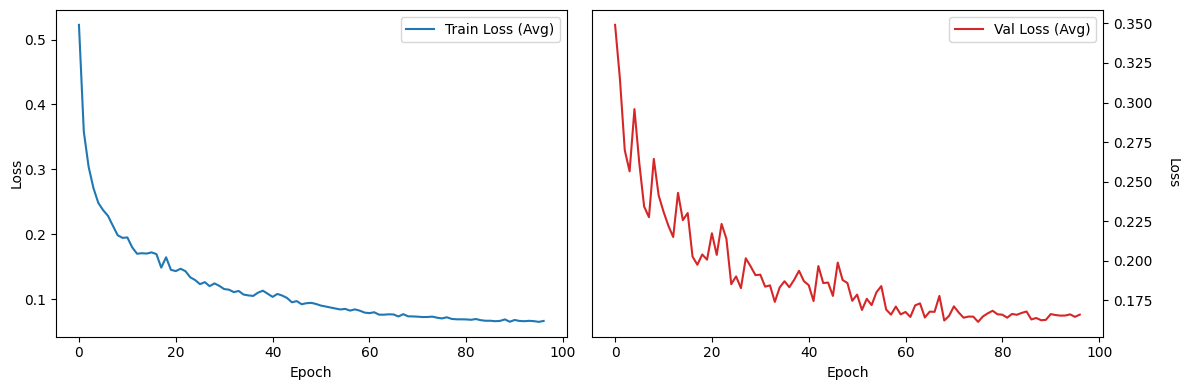

In [ ]:
# Average loss
plot_loss(
    train_history = train_history,
    val_history = val_history
)

## 11.2) Plot Summary Metrics

A **summary metric** refers to a metric that summarizes the model's overall performance across all classes in the dataset. Examples of summary metrics include accuracy, mean/min/max Dice, and mean/min/max IoU.

Summary metric curves (metric vs evaluation epoch) can be plotted using the `plot_results.plot_summary_metrics()` function. This function has 2 required arguments:
  - **val_history** (`ValHistory`): Validation-phase history object.
  - **metric_specs** (`Dict[str, MetricSpec]`): Dictionary mapping metric names to metric specifications. These specifications must produce a scalar value when extracting and processing from `val_history.metrics.values`.

<br>

In this example, the `metric_specs` argument is simply set to the `log_metric_specs` dictionary used during training. This means that we are plotting the same summary metrics that were displayed during logging.

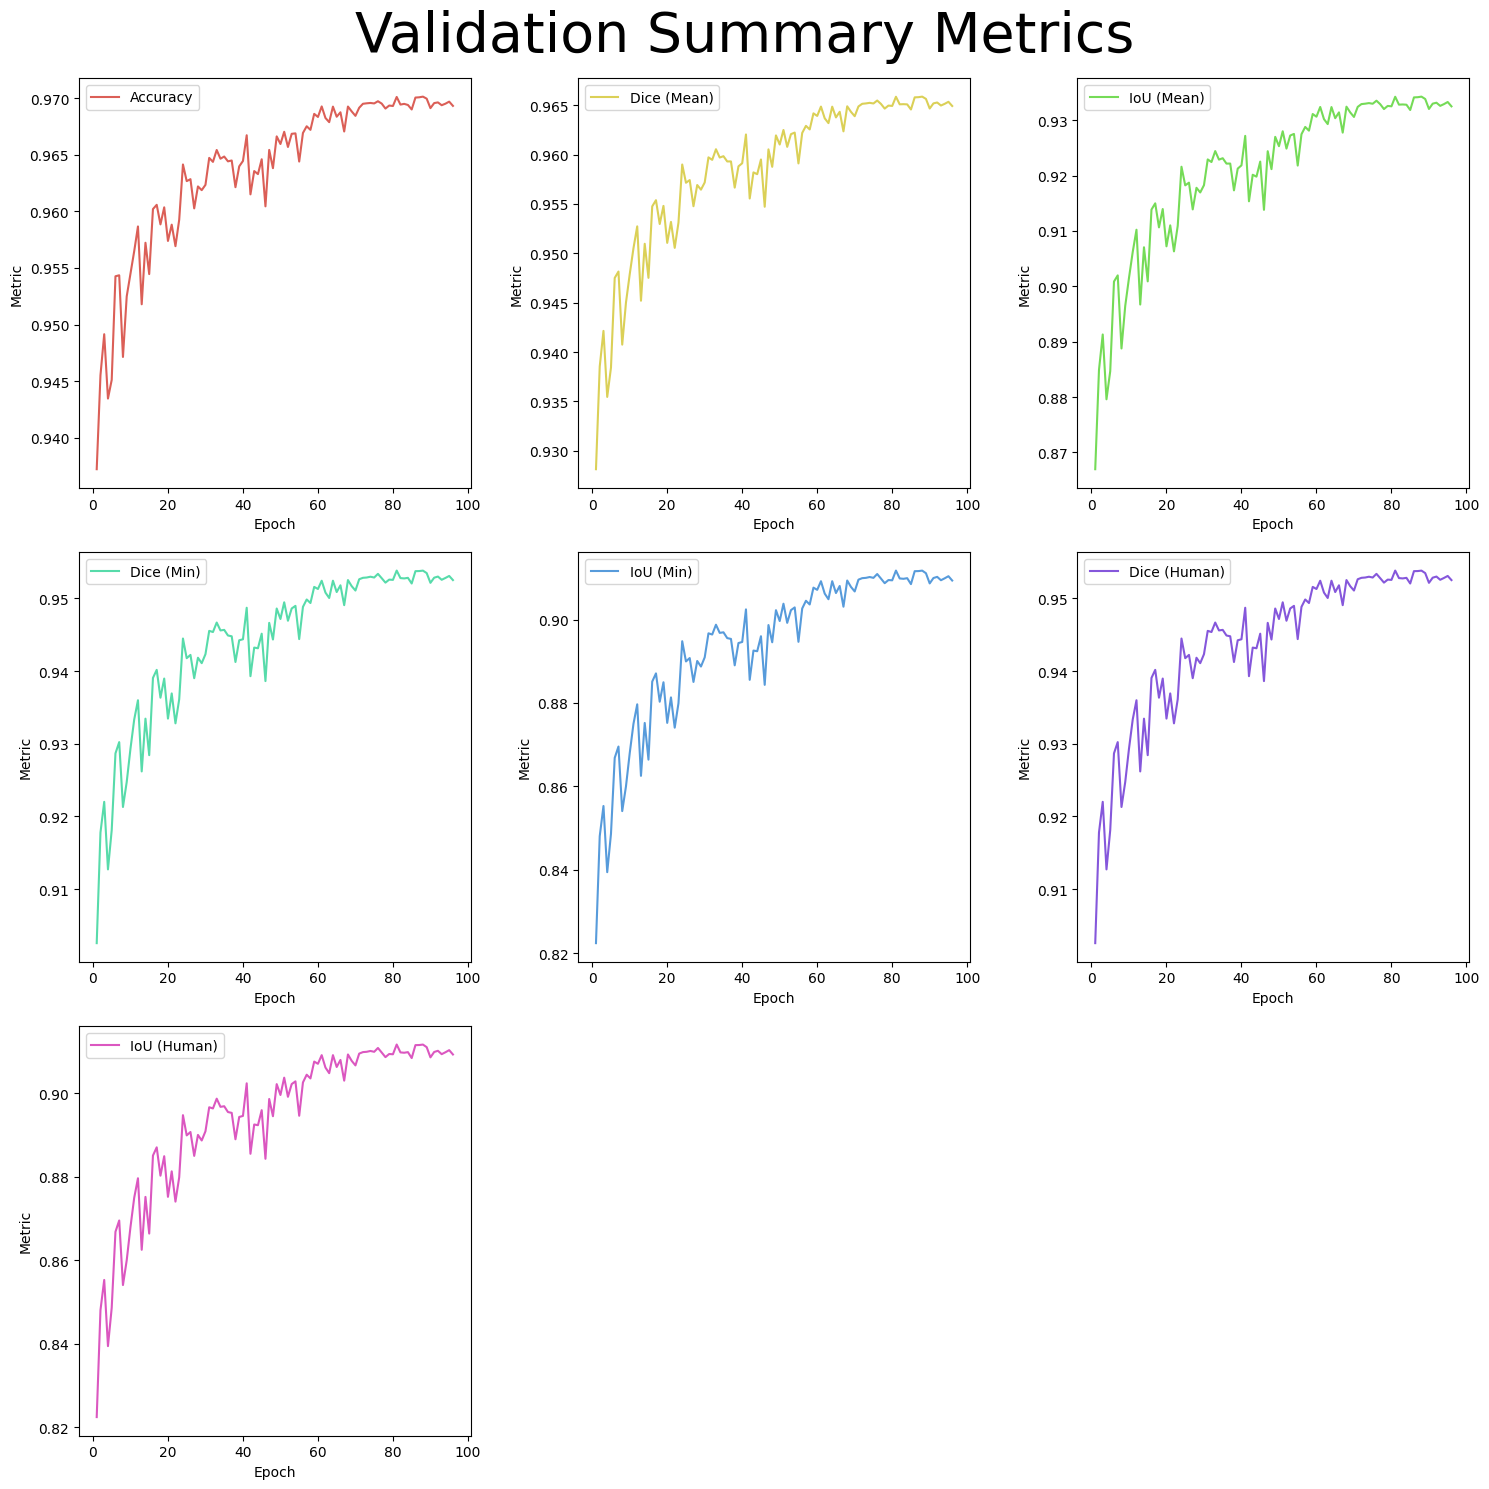

In [ ]:
# Summary metrics
plot_summary_metrics(
    val_history = val_history,
    metric_specs = log_metric_specs
)

## 11.3) Plot Class-Wise Metrics

A **class-wise metric** refers to a metric that measures the model's performance for each individual class in the dataset. When computed, class-wise metrics are generally returned as sequences of length `num_classes`, where each element corresponds to the metric value for the class at that index. Examples of class-wise metrics include Dice and IoU (all not aggregated).

Class-wise metric curves (metric vs evaluation epoch) can be plotted using the `plot_results.plot_class_metrics()` function. This function has the arguments:
  - **val_history** (`ValHistory`): Validation-phase history object.
  - **key_paths** (`List[str]`): List of dot-separated key paths within `val_history.metrics.values`. Each path must produce a sequence of class-wise tensors when extracting.
  - **class_names** (`List[str]`): List of class names.
  - **metric_labels** (optional, `List[str]`): Labels for the title of each class-wise metric subplot/panel. If not provided, the key paths in `key_paths` are used as titles.


The `plot_results.plot_class_metrics()` function will create a subplot for each class-wise metric in `key_paths`. Within each subplot, each class gets their own metric curve.

<br>

It is recommended to use this function only when there are a few classes in the dataset; otherwise, the subplots will appear very messy.

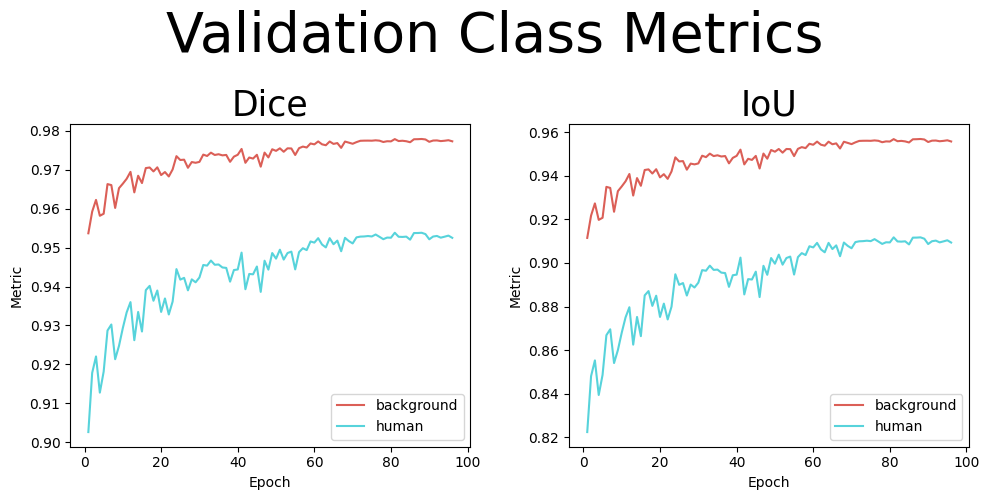

In [ ]:
# This is only recommended for datasets with a small number of classes
key_paths = ['seg.dice','seg.iou']
metric_labels = ['Dice', 'IoU']

# Class-wise metrics
plot_class_metrics(
    val_history = val_history,
    key_paths = key_paths,
    class_names = val_dataset.class_names,
    metric_labels = metric_labels
)

# 12) Plot Predictions from Best Model

There are 2 functions available for computing and plotting segmentation predictions for a list of images:
  - `plot_preds.plot_seg_preds_collage`
  - `plot_preds.plot_seg_preds_overlay`

## 12.1) Collage Format

The `plot_preds.plot_seg_preds_collage` function computes prediction masks and displays them side-by-side with their corresponding input images and optional target masks.

This function takes in the arguments:
  - **model** (`nn.Module`): Semantic segmentation model.
  - **imgs** (`Image(s)`): Images to predict on and plot. The supported input formats are:
    - A single PIL image
    - A single 3D tensor of shape `(channels, height, width)`
    - A list of images (each element is a PIL image or 3D tensor)
    - A batched 4D tensor of shape `(batch_size, channels, height, width)`
  - **idx_to_rgb** (`dict`): Index-to-RGB mapping used for converting index masks to RGB masks for plotting.
  - **transforms** (optional, `v2.Compose`): Transforms used to preprocess the images before passing them into the model. If provided, this should be the same pipeline used during validation and it must produce tensors. If not provided, the images must already be tensors.
  - **pred_rev_sizing_mode** (optional, `Literal['resize', 'letterbox']`): If provided, restores the prediction masks to their original image sizes by reversing the sizing method in `transforms` (letterbox or resize).
  - **targ_masks** (optional, `Mask(s)`): Optional target masks for the images. These may be index or RGB masks. The supported input formats are:
    - A single PIL image
    - A tensor of a single mask:
      - RGB mode: Shape must be `(3, height, width)`
      - Index mode: Shape must be `(height, width)`
    - A list of masks (each element is a PIL image or tensor)
    - A batched tensor of multiple masks:
        - RGB mode: Shape must be `(batch_size, 3, height, width)`
        - Index mode: Shape must be `(batch_size, height, width)`
  - **targ_mode** (optional, `Literal['rgb', 'index']`): The mode of the optional target masks (`targ_masks`).
  - **fill_rgb** (`Tuple[int, int, int]`): RGB tuple used to fill in pixels whose index is not present in `idx_to_rgb`. Default is `(114, 114, 114)`.
  - **visible_classes** (optional, `List[str]`): List of classes to set as visible in the prediction masks and `targ_masks`. If provided, classes not in this list will be fully transparent.
  - **include_legend** (`bool`): Whether to include a legend that maps the unique colors in the prediction masks and `targ_masks` to their class names. Default is `False`.
  - **rgb_to_class** (optional, `dict`): RGB-to-class mapping. This is required if `visible_classes` is provided or if `include_legend=True`.
  - **memory_format** (optional, `torch.memory_format`): Memory format to convert images to before predicting. If provided, this should ideally be the same memory format as the model. If not provided, no memory format conversion is applied.

<br>

In this example, we randomly sample 10 images from the validation dataset.

As explained in **2.2) Set up Datasets**, we use the `.get_base_item(index)` method of `val_dataset` to obtain the non-transformed samples and the `.transform_pipeline` attribute to obtain the exact transform pipeline used during validation.

Additionally, we can get the mappings from the following attributes:
  - `.idx_to_rgb`: Index-to-RGB mapping of the dataset.
  - `.rgb_to_class`: RGB-to-class mapping of the dataset.

**Note**: If the target masks are in RGB format, `idx_to_rgb` and `rgb_to_class` must use the same color encoding as the target masks. Otherwise, the target and predicted masks will not show consistent colors and the legend will also be incorrect.


In [ ]:
# Get required mappings
idx_to_rgb = val_dataset.idx_to_rgb
rgb_to_class = val_dataset.rgb_to_class

print(f'Index-to-RGB Mapping: {idx_to_rgb}') # This includes the ignore encoding
print(f'RGB-to-Class Mapping: {rgb_to_class}')


# Get samples
num_samps = 10

samp_idxs = random.sample(range(len(val_dataset)), num_samps)
samps = [val_dataset.get_base_item(i) for i in samp_idxs]

imgs = [s['image'] for s in samps]
targ_masks = [s['mask'] for s in samps]

Index-to-RGB Mapping: {1: (255, 255, 255), 0: (0, 0, 0), -100: (114, 114, 114)}
RGB-to-Class Mapping: {(255, 255, 255): 'human', (0, 0, 0): 'background'}


In [ ]:
# Plot predictions in collage format
plot_seg_preds_collage(
    model = best_segformer,
    imgs = imgs,
    idx_to_rgb = idx_to_rgb,
    transforms = val_dataset.transform_pipeline,
    pred_rev_sizing_mode = SIZING_MODE,
    targ_masks = targ_masks,
    targ_mode = 'rgb',

    # # Uncomment to show the legend
    # include_legend = True,
    # rgb_to_class = rgb_to_class,

    memory_format = torch.channels_last
)

Output hidden; open in https://colab.research.google.com to view.

## 12.2) Overlay Format

The `plot_preds.plot_seg_preds_overlay` function computes prediction masks and overlays them on top of their corresponding input images.

This function takes in the arguments:
  - **model** (`nn.Module`): Semantic segmentation model.
  - **imgs** (`Image(s)`): Images to predict on and plot. The supported input formats are:
    - A single PIL image
    - A single 3D tensor of shape `(channels, height, width)`
    - A list of images (each element is a PIL image or 3D tensor)
    - A batched 4D tensor of shape `(batch_size, channels, height, width)`
  - **idx_to_rgb** (`dict`): Index-to-RGB mapping used for converting index masks to RGB masks for plotting.
  - **transforms** (optional, `v2.Compose`): Transforms used to preprocess the images before passing them into the model. If provided, this should be the same pipeline used during validation and it must produce tensors. If not provided, the images must already be tensors.
  - **pred_rev_sizing_mode** (optional, `Literal['resize', 'letterbox']`): If provided, restores the prediction masks to their original image sizes by reversing the sizing method in `transforms` (letterbox or resize).
  - **fill_rgb** (`Tuple[int, int, int]`): RGB tuple used to fill in pixels whose index is not present in `idx_to_rgb`. Default is `(114, 114, 114)`.
  - **visible_classes** (optional, `List[str]`): List of classes to set as visible in the prediction masks and `targ_masks`. If provided, classes not in this list will be fully transparent.
  - **include_legend** (`bool`): Whether to include a legend that maps the unique colors in the prediction masks to their class names. Default is `False`.
  - **rgb_to_class** (optional, `dict`): RGB-to-class mapping. This is required if `visible_classes` is provided or if `include_legend=True`.
  - **memory_format** (optional, `torch.memory_format`): Memory format to convert images to before predicting. If provided, this should ideally be the same memory format as the model. If not provided, no memory format conversion is applied.
  - **pred_alpha** (Union[int, float]): Alpha value used for the overlaid prediction masks. Default is `0.5`.

<br>

In this example, we use the same samples as those from **12.1) Collage Format**.

Since the overlay format does not plot optional target masks, the mappings (`idx_to_rgb` and `rgb_to_class`) do not need to follow the dataset's original color encoding. We have full liberty on what colors are used to represent each class. The only requirement is that the color assignments should be consistent between the mappings.

In [ ]:
# Since overlay format doesn't use target masks, we can set the color mappings to anything we want.
idx_to_rgb = {1: (0, 255, 255), 0: (0, 0, 0)}
rgb_to_class = {(0, 255, 255): 'human', (0, 0, 0): 'background'}


# Plot predictions in overlay format
plot_seg_preds_overlay(
    model = best_segformer,
    imgs = imgs,
    idx_to_rgb = idx_to_rgb,
    transforms = val_dataset.transform_pipeline,
    pred_rev_sizing_mode = SIZING_MODE,

    visible_classes = ['human'],
    include_legend = False,
    rgb_to_class = rgb_to_class,

    pred_alpha = 0.4,
    memory_format = torch.channels_last
)

Output hidden; open in https://colab.research.google.com to view.

# 13) (Optional) Download Saved Files from Google Colab

Instead of saving the full checkpoint file, the `engine.checkpoints.separate_checkpoint()` function can be used to split the checkpoint into multiple `.pth` files. Each file contains the saved state dictionary for a different checkpoint component (e.g. model, optimizer, scheduler, and history objects).

To **download all saved files** from this Google Colab example to out local machine, we first zip the save directory (`SAVE_DIR`) and then download the zipped file using `files.download()`.

In [ ]:
# # If needed, separate checkpoint into multiple .pth files
# separate_checkpoint(
#     checkpoint_path = save_settings.ckpt_path,
#     base_dir = SAVE_DIR
# )

In [ ]:
if IN_COLAB:
    from google.colab import files
    %cd /content/segformer-pytorch
    !zip -r human_nonhuman.zip human_nonhuman
    files.download('human_nonhuman.zip')

/content/segformer-pytorch
  adding: human_nonhuman/ (stored 0%)
  adding: human_nonhuman/segformer_b1/ (stored 0%)
  adding: human_nonhuman/segformer_b1/best_mod.pth (deflated 7%)
  adding: human_nonhuman/segformer_b1/checkpoint.pth (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/content
